# **SALES ANALYSIS & BASIC REPORTING**
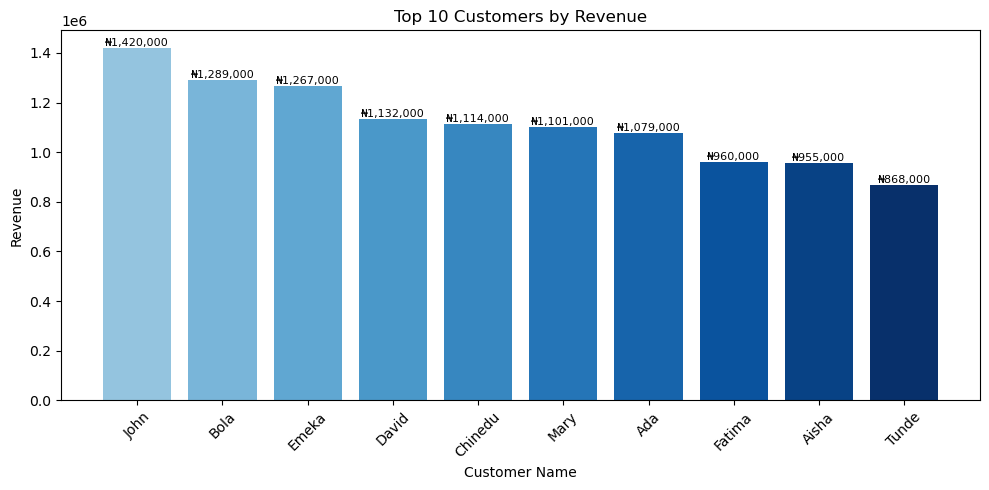

This project demonstrates my ability to transform raw sales data into actionable business insights using Python.
The objective was to analyze sales performance, identify key business metrics, and generate reports that can support better business decisions.


**The goal of this project was to:**
* Understand overall sales performance
* Calculate key business KPIs
* Identify trends and patterns
* Create summary reports for decision-making
* Export findings into a professional Excel report


**Dataset**


The [dataset](https://docs.google.com/spreadsheets/d/1ncSbKWQvZuRHVna1ICpxYq6geYqaQohX/edit?usp=sharing&ouid=104795647098572756661&rtpof=true&sd=true) contained sales transaction records including:


* Customer information
* Products
* Sales revenue
* Transaction dates


**Tools Used**
* Python
* Pandas
* NumPy
* Excel


### **Libraries**

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [79]:
!pip install --upgrade kaleido

In [80]:
import sys
!{sys.executable} -m pip install -U kaleido

In [81]:
# load data
sales = pd.read_csv("/content/Clean_sales_data.xls")

In [82]:
sales.head()

,ID,Customer_name,Product,Price,Quantity,Order_date
0,0,John,Shoes,12000.0,5.0,2025-02-22
1,1,David,Jeans,5000.0,1.0,2025-04-30
2,2,Emeka,Dress,12000.0,1.0,2025-05-23
3,3,Mary,Jeans,15000.0,2.0,2025-06-22
4,4,John,Jeans,8000.0,2.0,2025-06-11


In [83]:
# data info
sales.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             482 non-null    int64  
 1   Customer_name  482 non-null    object 
 2   Product        482 non-null    object 
 3   Price          482 non-null    float64
 4   Quantity       482 non-null    float64
 5   Order_date     467 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 22.7+ KB


### **Summary Statistics**

This gives the
* Mean
* Min / Max
* Standard Deviation
of the dataset

In [84]:
sales.describe()

,ID,Price,Quantity
count,482.000000,482.000000,482.000000
mean,248.031120,9265.560166,2.580913
std,143.962952,2728.919695,1.297162
min,0.000000,5000.000000,1.000000
25%,121.250000,7000.000000,1.000000
50%,249.500000,9000.000000,2.000000
75%,371.750000,10000.000000,3.000000
max,499.000000,15000.000000,5.000000


In [85]:
# creating a revenue column

sales["Revenue"] = sales["Quantity"] * sales["Price"]
sales.head()

,ID,Customer_name,Product,Price,Quantity,Order_date,Revenue
0,0,John,Shoes,12000.0,5.0,2025-02-22,60000.0
1,1,David,Jeans,5000.0,1.0,2025-04-30,5000.0
2,2,Emeka,Dress,12000.0,1.0,2025-05-23,12000.0
3,3,Mary,Jeans,15000.0,2.0,2025-06-22,30000.0
4,4,John,Jeans,8000.0,2.0,2025-06-11,16000.0


In [86]:
# more useful summary

summary = {
    "Total_Row": len(sales),
    "Total_Orders": sales["ID"].nunique(),
    "Total_Customer": sales["Customer_name"].nunique(),
    "Total_Products": sales["Product"].nunique(),
    "Total_Revenue": f"₦{sales["Revenue"].sum():,.0f}"
}

summary

{'Total_Row': 482,
 'Total_Orders': 476,
 'Total_Customer': 11,
 'Total_Products': 9,
 'Total_Revenue': '₦11,555,000'}

### **KPI Calculations (Business Metrics)**

In [87]:
# Total_revenue
Total_Revenue = sales["Revenue"].sum()

print(f"Total Revenue: ₦{Total_Revenue:,.2f}")

Total Revenue: ₦11,555,000.00


In [88]:
# Total_orders

Total_Orders = sales["ID"].nunique()
print(f"Total_Orders: {Total_Orders:}")

Total_Orders: 476


In [89]:
# Total_customers

Total_Customers = sales["Customer_name"].nunique()
print(f"Total_Customers: {Total_Customers:}")

Total_Customers: 11


In [90]:
# Average Order Value (AOV)

AOV = Total_Revenue / Total_Orders
print(f"AOV: ₦{AOV:,.2f}")

AOV: ₦24,275.21


In [91]:
# Average quantity per order

Avg_qty = sales["Quantity"].mean()
print(f"Avg_qty: {Avg_qty:.2f}")

Avg_qty: 2.58


In [92]:
Avg_qty = sales["Quantity"].mean()
print(f"Avg_qty: {Avg_qty:.0f}")

Avg_qty: 3


### **Pivot Tables & Visualizations**

#### **Products By Revenue**

In [93]:


# aggregate
Product_sales = (
    sales.groupby("Product")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

Product_sales["Revenue"] = Product_sales["Revenue"].apply(
    lambda x: f"₦{x:,.0f}"
)

Product_sales

,Product,Revenue
0,Dress,"₦1,680,000"
1,Bag,"₦1,538,000"
2,Shoes,"₦1,420,000"
3,Watch,"₦1,415,000"
4,Jeans,"₦1,357,000"
5,Phone Case,"₦1,355,000"
6,Shirt,"₦1,268,000"
7,Cap,"₦1,151,000"
8,Unknown,"₦371,000"


In [94]:

# plotly visualization
fig = px.bar(
    Product_sales,
    x="Product",
    y="Revenue",
    title="Products by Revenue"
)

fig.show()

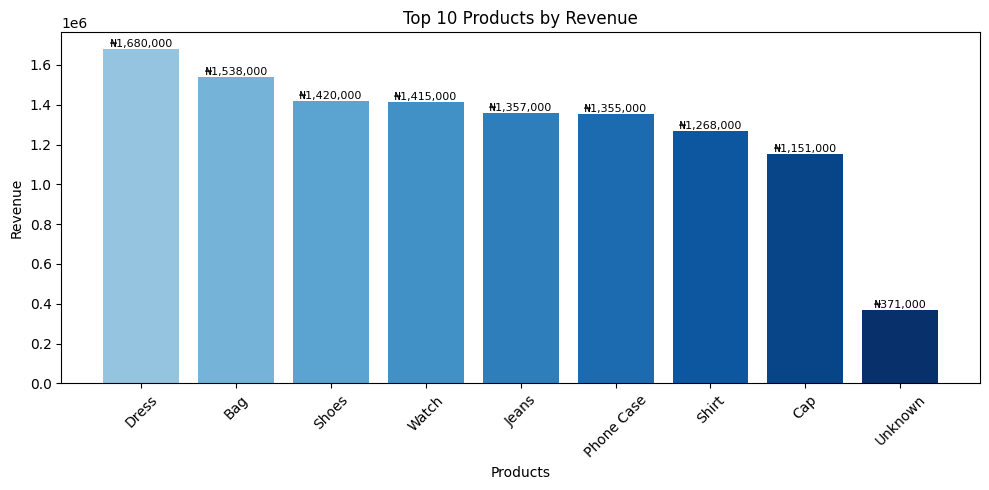

In [95]:
# matplotlib visualization

plt.figure(figsize=(10, 5))

colours = plt.cm.Blues(
    np.linspace(0.4, 1, len(Product_sales))
)

bars = plt.bar(
    Product_sales["Product"],
    product_sales["Revenue"],
    color = colours
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Products")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

# add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"₦{bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

### **Product Quantity Analysis**

In [96]:
# product quantity analysis

# aggregate
product_qty = sales.groupby("Product")["Quantity"].sum().reset_index()

fig = px.bar(
    product_qty,
    x="Product",
    y="Quantity",
    title="Product Demand (Quantity Sold)"
)

#plotly visualisation
fig.show()

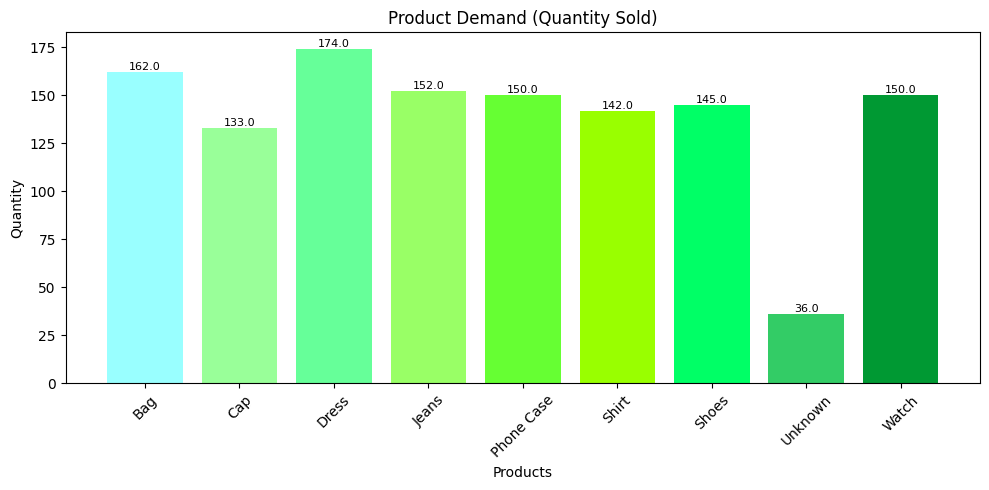

In [97]:
# matplotlib visualization

plt.figure(figsize=(10, 5))

colours = ["#99FFFF", "#99FF99", "#66FF99", "#99FF66", "#66FF33", "#99FF00", "#00FF66", "#33CC66", "#009933"]

bars = plt.bar(
    product_qty["Product"],
    product_qty["Quantity"],
    color = colours
)

plt.title("Product Demand (Quantity Sold)")
plt.xlabel("Products")
plt.ylabel("Quantity")

plt.xticks(rotation=45)

# add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

#### **Top Customers By Money Spent**

In [98]:
# aggregate

Customer_sales = (
    sales.groupby("Customer_name")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

Customer_sales["Revenue"] = Customer_sales["Revenue"].apply(
    lambda x: f"₦{x:,.0f}"
)

Customer_sales

,Customer_name,Revenue
0,John,"₦1,420,000"
1,Bola,"₦1,289,000"
2,Emeka,"₦1,267,000"
3,David,"₦1,132,000"
4,Chinedu,"₦1,114,000"
5,Mary,"₦1,101,000"
6,Ada,"₦1,079,000"
7,Fatima,"₦960,000"
8,Aisha,"₦955,000"
9,Tunde,"₦868,000"


In [99]:


# plotly visualization
fig = px.bar(
    Customer_sales,
    x="Customer_name",
    y="Revenue",
    title="Top 10 Customers by Revenue"
)

fig.show()

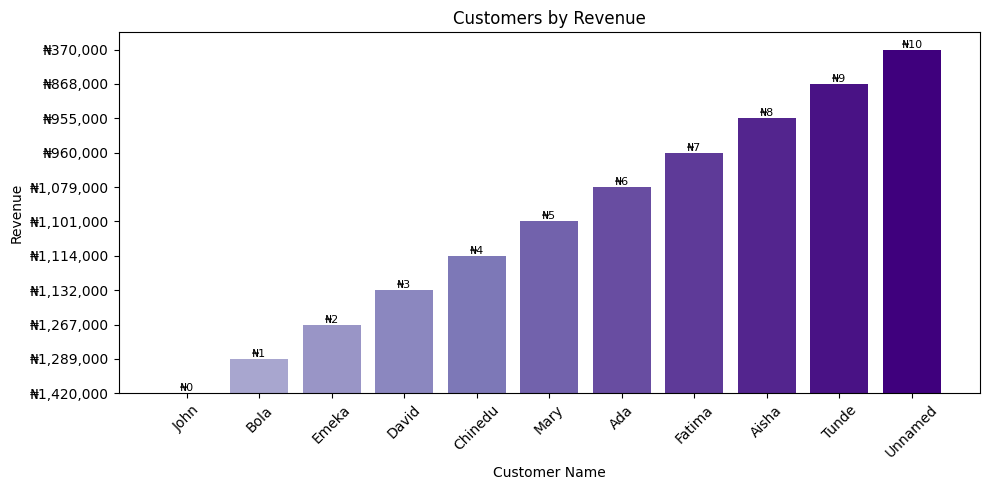

In [100]:
# matplotlib visualization
plt.figure(figsize=(10, 5))

colours = plt.cm.Purples(
    np.linspace(0.4, 1, len(Customer_sales))
)

bars = plt.bar(
    Customer_sales["Customer_name"],
    Customer_sales["Revenue"],
    color = colours
)

plt.title("Customers by Revenue")
plt.xlabel("Customer Name")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

# add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"₦{bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

### **Spending Distribution**

In [101]:
# plotly visualization
fig = px.histogram(sales, x="Revenue", nbins=20, title="Customer Spending Distribution")
fig.show()

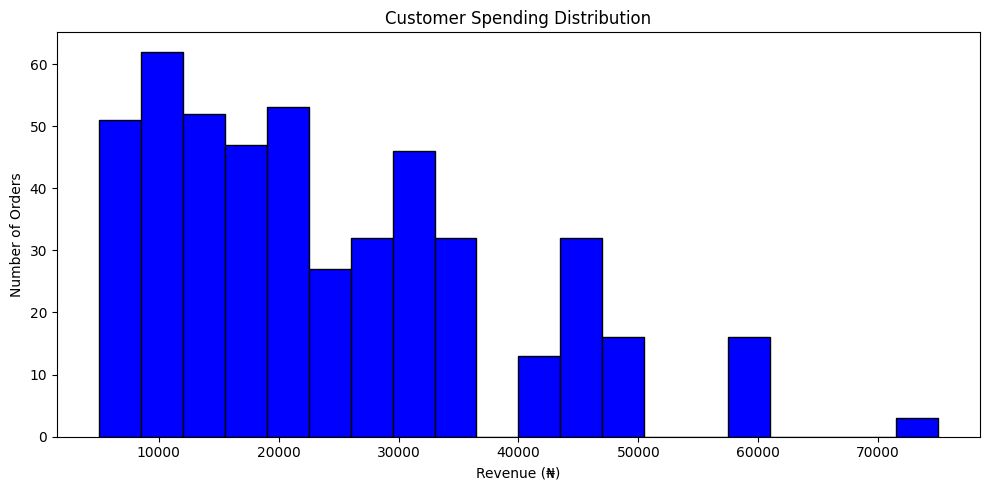

In [102]:
# matplotlib visualization
plt.figure(figsize=(10, 5))

plt.hist(
    sales["Revenue"],
    bins=20,
    edgecolor="black",
    color = "Blue"
)

plt.title("Customer Spending Distribution")
plt.xlabel("Revenue (₦)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

#### **Sales Trend (Sales By Date)**

In [103]:
# aggregate
Daily_sales = sales.groupby("Order_date")["Revenue"].sum()

Daily_sales = (
    sales.groupby("Order_date")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

Daily_sales["Revenue"] = Daily_sales["Revenue"].apply(
    lambda x: f"₦{x:,.0f}"
)

Daily_sales

,Order_date,Revenue
0,2025-06-04,"₦165,000"
1,2025-11-11,"₦134,000"
2,2025-06-19,"₦119,000"
3,2025-06-13,"₦115,000"
4,2025-08-28,"₦111,000"
...,...,...
257,2025-08-14,"₦7,000"
258,2025-06-16,"₦5,000"
259,2025-04-30,"₦5,000"
260,2025-07-11,"₦5,000"


In [104]:


# plotly visualization
fig = px.line(
    Daily_sales,
    x="Order_date",
    y="Revenue",
    title="Revenue Trend Over Time"
)

fig.show()

#### **Monthly Sales**

In [105]:
sales["Order_date"]= pd.to_datetime(sales["Order_date"], errors = "coerce")
sales["Month"] = sales["Order_date"].dt.to_period("M")

#aggregate
Monthly_sales = (
    sales.groupby("Month")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

Monthly_sales["Revenue"] = Monthly_sales["Revenue"].apply(
    lambda x: f"₦{x:,.0f}"
)

Monthly_sales

,Month,Revenue
0,2025-08,"₦1,224,000"
1,2025-07,"₦1,149,000"
2,2025-12,"₦1,098,000"
3,2025-03,"₦1,084,000"
4,2025-06,"₦1,008,000"
5,2025-11,"₦983,000"
6,2025-05,"₦878,000"
7,2025-10,"₦851,000"
8,2025-04,"₦827,000"
9,2025-02,"₦815,000"


### **Basic Business Report**

In [106]:
Report = f"""
SALES REPORT

=================
SUMMARY STATISTICS
=================
Total Revenue: ₦{Total_Revenue:,.2f}
Total Orders: {Total_Orders}
Total Customers: {Total_Customers}
Average Order Value: ₦{AOV:,.2f}

==================
TOP PRODUCTS
==================
{Product_sales.head()}

==================
TOP CUSTOMERS
==================
{Customer_sales.head()}

===================
INSIGHT SUMMARY
===================
- Revenue is concentrated in top-performing products
- Customer spending varies significantly
- Sales trend can be analyzed over time using monthly grouping
"""


print(Report)


SALES REPORT

SUMMARY STATISTICS
Total Revenue: ₦11,555,000.00
Total Orders: 476
Total Customers: 11
Average Order Value: ₦24,275.21

TOP PRODUCTS
  Product     Revenue
0   Dress  ₦1,680,000
1     Bag  ₦1,538,000
2   Shoes  ₦1,420,000
3   Watch  ₦1,415,000
4   Jeans  ₦1,357,000

TOP CUSTOMERS
  Customer_name     Revenue
0          John  ₦1,420,000
1          Bola  ₦1,289,000
2         Emeka  ₦1,267,000
3         David  ₦1,132,000
4       Chinedu  ₦1,114,000

INSIGHT SUMMARY
- Revenue is concentrated in top-performing products
- Customer spending varies significantly
- Sales trend can be analyzed over time using monthly grouping



### **Export to Excel**



In [107]:
with pd.ExcelWriter("Sales_report.xlsx") as writer:
    sales.to_excel(writer, sheet_name = "Raw Data", index = False)
    Product_sales.to_excel(writer, sheet_name = "Product Sales")
    Customer_sales.to_excel(writer, sheet_name = "Customer Sales")
    Monthly_sales.to_excel(writer, sheet_name = "Monthly Sales")

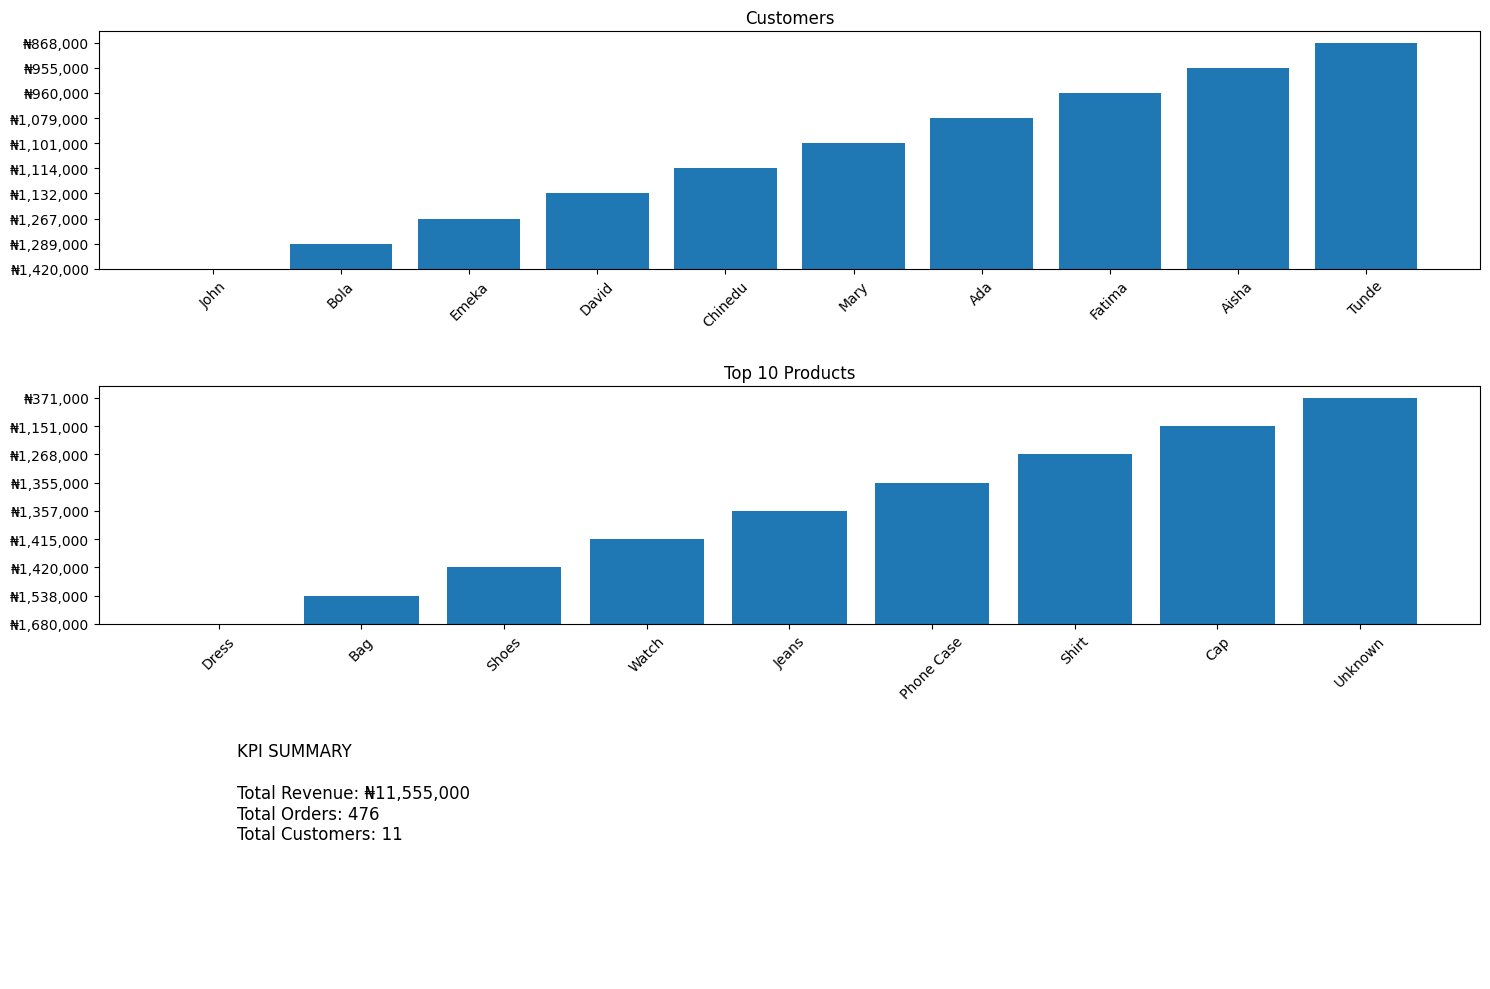

In [108]:
# mini dashboard

fig, axes = plt.subplots(3, 1, figsize=(15, 10))


# ---------------------------
# 1. CUSTOMERS (Top Left)
# ---------------------------
customers = Customer_sales.head(10)

axes[0].bar(
    customers["Customer_name"],
    customers["Revenue"]
)

axes[0].set_title("Customers")
axes[0].tick_params(axis='x', rotation=45)

# ---------------------------
# 2. TOP PRODUCTS (Top Right)
# ---------------------------
top_products = Product_sales.head(10)

axes[1].bar(
    top_products["Product"],
    top_products["Revenue"]
)

axes[1].set_title("Top 10 Products")
axes[1].tick_params(axis='x', rotation=45)

# ---------------------------
# 3. KPI SUMMARY (Bottom Right)
# ---------------------------
axes[2].axis("off")

total_revenue = sales["Revenue"].sum()
total_orders = sales["ID"].nunique()
total_customers = sales["Customer_name"].nunique()

kpi_text = f"""
KPI SUMMARY

Total Revenue: ₦{total_revenue:,.0f}
Total Orders: {total_orders}
Total Customers: {total_customers}
"""

axes[2].text(
    0.1, 0.5,
    kpi_text,
    fontsize=12
)

# ---------------------------
# FINAL LAYOUT
# ---------------------------
plt.tight_layout()
plt.show()